# House Prices 이상치 진단

## tl;dr

- 단순 IQR 규칙은 정상적인 고가·대면적 주택까지 함께 잡으므로 삭제 규칙으로 쓰지 않는다.
- `GrLivArea > 4,000`인 4건 중 **Id 1299**가 고정 5-fold Ridge에서 학습 영향이 가장 크다. 이 행만 fold 학습에서 제외하면 CV 평균이 **0.131910 → 0.127303**으로 낮아졌고, 영향을 받는 4개 fold 모두 개선됐다.
- **Id 524**는 가격 관계상 매우 큰 OOF 잔차와 1년 미래 리모델링 연도 오류가 있지만, 단독 학습 제외 효과는 거의 0이다. 행 삭제보다 연도 anomaly flag가 우선이다.
- **Id 692와 1183**은 큰 면적의 고가 주택으로, 둘을 제외하면 CV가 **0.136530**으로 악화됐다. 극단값이지만 현재 근거로는 삭제하면 안 된다.
- test predictor는 분석하지 않으며 제출 형식 확인과 blind inference에만 사용한다.

결론은 **Id 1299만 제거 후보**, 나머지는 보존하면서 오류 flag·robust preprocessing·모델별 민감도 검증을 적용하는 것이다.

## Context & Methods

### Key Assumptions

- 관측 단위는 Ames 주택 거래 1건이며 `Id`는 유일한 행 식별자다.
- EDA와 모델 선택에는 원본 `data/train.csv`만 사용한다. test는 제출 형식 확인과 blind inference 외에는 열지 않는다. `NA`/`None` 리터럴은 구조적 부재일 수 있어 `keep_default_na=False`로 보존한다.
- 이상치 후보는 (1) 핵심 연속형 변수의 3×IQR outer fence, (2) 연도·면적 간 논리 규칙, (3) 두 모델의 OOF 로그 잔차, (4) 고정-fold 학습 제외 민감도로 찾는다.
- IQR 초과는 데이터 오류가 아니라 후보 표시다. 실제 삭제 권고는 동일 fold에서 validation 행을 모두 유지한 학습 제외 실험으로 판단한다.
- OOF 잔차 상위 행을 같은 OOF에서 선택한 뒤 제거하면 선택 편향이 생기므로, 잔차 순위만으로 삭제 결론을 내리지 않는다.

In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str((ROOT / "by_ai").resolve()))

from src.data import FEATURE_GROUPS, build_linear_preprocessor, load_house_prices
from src.experiments import evaluate_sklearn_cv, make_folds

TRAIN_PATH = ROOT / "data" / "train.csv"
RIDGE_OOF_PATH = ROOT / "by_ai" / "artifacts" / "predictions" / "AI-20260719T041029Z-ALL-FEATURES_oof.csv"
MLP_OOF_PATH = ROOT / "by_ai" / "artifacts" / "predictions" / "AI-20260719T041029Z-NN-ARCH-256-128-64_oof.csv"
METRICS_PATH = ROOT / "reports" / "outlier_metrics.json"

train = load_house_prices(TRAIN_PATH)
ridge_oof = pd.read_csv(RIDGE_OOF_PATH)
mlp_oof = pd.read_csv(MLP_OOF_PATH)

assert train.shape == (1460, 81)
assert train["Id"].is_unique
assert ridge_oof["Id"].equals(mlp_oof["Id"])
assert ridge_oof["Id"].equals(train["Id"])

def numeric(frame: pd.DataFrame, column: str) -> pd.Series:
    return pd.to_numeric(frame[column], errors="coerce")

def records(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient="records"))

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

print(f"train={train.shape}, duplicate train Id=0")

train=(1460, 81), duplicate train Id=0


## Data

In [2]:
source_summary = pd.DataFrame(
    [
        {"source": "train.csv", "rows": len(train), "columns": train.shape[1], "sha256": sha256(TRAIN_PATH)},
        {"source": "Ridge OOF", "rows": len(ridge_oof), "columns": ridge_oof.shape[1], "sha256": sha256(RIDGE_OOF_PATH)},
        {"source": "MLP OOF", "rows": len(mlp_oof), "columns": mlp_oof.shape[1], "sha256": sha256(MLP_OOF_PATH)},
    ]
)
display(source_summary)

,source,rows,columns,sha256
0,train.csv,1460,81,1e18addf81e5e4d347cc17ee6075bbe4a42b7fa26b9e5b...
1,Ridge OOF,1460,6,f7f00f8e195558dadf1109da702a63c8dbec21286e01bd...
2,MLP OOF,1460,6,bf035dd830de6980016873f996f1e87dc9d4b44637932d...


## Results

### 1. Robust 단변량 후보

3×IQR outer fence를 사용한다. 0이 대부분인 변수는 Q1=Q3=0이 되어 시설이 있는 모든 행을 이상치로 오인할 수 있으므로, 여기서는 가격·면적·차고처럼 연속적인 핵심 변수만 본다.

In [3]:
iqr_columns = [
    "SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF",
    "1stFlrSF", "2ndFlrSF", "GarageArea", "MasVnrArea",
    "WoodDeckSF", "OpenPorchSF",
]
iqr_rows = []
for column in iqr_columns:
    values = numeric(train, column).dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    mask = (numeric(train, column) < lower) | (numeric(train, column) > upper)
    candidates = train.loc[mask, ["Id", column]].copy()
    candidates[column] = pd.to_numeric(candidates[column], errors="coerce")
    top_ids = candidates.sort_values(column, ascending=False)["Id"].head(8).astype(int).tolist()
    iqr_rows.append(
        {
            "feature": column,
            "lower_outer_fence": float(lower),
            "upper_outer_fence": float(upper),
            "candidate_count": int(mask.sum()),
            "candidate_rate": float(mask.mean()),
            "largest_candidate_ids": top_ids,
        }
    )
iqr_summary = pd.DataFrame(iqr_rows)
display(iqr_summary)

,feature,lower_outer_fence,upper_outer_fence,candidate_count,candidate_rate,largest_candidate_ids
0,SalePrice,-122100.00,466075.00,12,0.008219,"[692, 1183, 1170, 899, 804, 1047, 441, 770]"
1,GrLivArea,-812.25,3718.50,4,0.002740,"[1299, 524, 1183, 692]"
2,LotArea,-4590.50,23745.50,34,0.023288,"[314, 336, 250, 707, 452, 1299, 1397, 770]"
3,TotalBsmtSF,-711.75,2805.75,5,0.003425,"[1299, 333, 497, 524, 441]"
4,1stFlrSF,-645.75,2919.00,3,0.002055,"[1299, 497, 524]"
5,2ndFlrSF,-2184.00,2912.00,0,0.000000,[]
6,GarageArea,-390.00,1300.50,3,0.002055,"[1299, 582, 1191]"
7,MasVnrArea,-498.00,664.00,25,0.017123,"[298, 1170, 692, 116, 71, 809, 59, 982]"
8,WoodDeckSF,-504.00,672.00,3,0.002055,"[54, 1460, 1069]"
9,OpenPorchSF,-204.00,272.00,18,0.012329,"[1329, 496, 584, 855, 524, 876, 736, 997]"


`SalePrice` outer-fence 12건은 고가 주택 후보일 뿐 오류가 아니다. 반면 `GrLivArea` outer-fence는 정확히 Id 524, 692, 1183, 1299 네 건으로 좁혀진다. 이 네 건은 아래의 가격 관계와 학습 영향으로 다시 구분한다.

### 2. 도메인 논리 오류

In [4]:
def domain_rule_masks(frame: pd.DataFrame) -> dict[str, pd.Series]:
    return {
        "YearBuilt > YrSold": numeric(frame, "YearBuilt") > numeric(frame, "YrSold"),
        "YearRemodAdd > YrSold": numeric(frame, "YearRemodAdd") > numeric(frame, "YrSold"),
        "YearRemodAdd < YearBuilt": numeric(frame, "YearRemodAdd") < numeric(frame, "YearBuilt"),
        "GarageYrBlt > YrSold": numeric(frame, "GarageYrBlt") > numeric(frame, "YrSold"),
        "GarageYrBlt > 2026": numeric(frame, "GarageYrBlt") > 2026,
        "GarageCars=0 & GarageArea>0": (numeric(frame, "GarageCars") == 0) & (numeric(frame, "GarageArea") > 0),
        "GarageCars>0 & GarageArea=0": (numeric(frame, "GarageCars") > 0) & (numeric(frame, "GarageArea") == 0),
        "Basement component sum mismatch": (
            numeric(frame, "TotalBsmtSF")
            - numeric(frame, "BsmtFinSF1")
            - numeric(frame, "BsmtFinSF2")
            - numeric(frame, "BsmtUnfSF")
        ).abs() > 1e-9,
        "Living-area component sum mismatch": (
            numeric(frame, "GrLivArea")
            - numeric(frame, "1stFlrSF")
            - numeric(frame, "2ndFlrSF")
            - numeric(frame, "LowQualFinSF")
        ).abs() > 1e-9,
    }

logic_rows = []
logic_details = {}
for split_name, frame in [("train", train)]:
    for rule, mask in domain_rule_masks(frame).items():
        mask = mask.fillna(False)
        ids = frame.loc[mask, "Id"].astype(int).tolist()
        logic_rows.append({"split": split_name, "rule": rule, "count": len(ids), "ids": ids})
        if ids:
            detail_columns = [
                "Id", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold",
                "GrLivArea", "1stFlrSF", "GarageCars", "GarageArea",
            ]
            available = [column for column in detail_columns if column in frame]
            logic_details[f"{split_name}: {rule}"] = records(frame.loc[mask, available])

logic_summary = pd.DataFrame(logic_rows)
display(logic_summary[logic_summary["count"] > 0].reset_index(drop=True))
display(pd.DataFrame(logic_details["train: YearRemodAdd > YrSold"]).drop_duplicates("Id").sort_values("Id"))

,split,rule,count,ids
0,train,YearRemodAdd > YrSold,1,[524]


,Id,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold,GrLivArea,1stFlrSF,GarageCars,GarageArea
0,524,2007,2008,2007.0,2007,4676,3138,3,884


Train에서는 Id 524의 `YearRemodAdd=2008 > YrSold=2007` 한 건만 확인된다. Test predictor는 분석하지 않는다.

### 3. 두 모델의 OOF 로그 잔차

In [5]:
oof_summaries = []
top_ids_by_model = {}
oof_frames = {}
for name, frame in [("Ridge all-features", ridge_oof.copy()), ("final MLP", mlp_oof.copy())]:
    frame["log_residual"] = frame["actual_log1p"] - frame["predicted_log1p"]
    frame["abs_log_residual"] = frame["log_residual"].abs()
    top_n = int(np.ceil(len(frame) * 0.01))
    top = frame.nlargest(top_n, "abs_log_residual")
    oof_summaries.append(
        {
            "model": name,
            "OOF_RMSLE": float(np.sqrt(np.mean(frame["log_residual"] ** 2))),
            "top_1pct_n": top_n,
            "top_1pct_abs_residual_threshold": float(top["abs_log_residual"].min()),
            "top_1pct_squared_error_share": float(
                (top["log_residual"] ** 2).sum() / (frame["log_residual"] ** 2).sum()
            ),
        }
    )
    top_ids_by_model[name] = set(top["Id"].astype(int))
    oof_frames[name] = frame

oof_summary = pd.DataFrame(oof_summaries)
display(oof_summary)

consensus_ids = sorted(
    top_ids_by_model["Ridge all-features"] & top_ids_by_model["final MLP"]
)
consensus = (
    train.merge(
        oof_frames["Ridge all-features"][["Id", "log_residual", "abs_log_residual", "predicted_saleprice"]],
        on="Id",
    )
    .merge(
        oof_frames["final MLP"][["Id", "log_residual", "abs_log_residual", "predicted_saleprice"]],
        on="Id",
        suffixes=("_ridge", "_mlp"),
    )
)
consensus = consensus[consensus["Id"].isin(consensus_ids)].copy()
consensus["price_per_living_sf"] = consensus["SalePrice"] / consensus["GrLivArea"]
consensus_columns = [
    "Id", "SalePrice", "GrLivArea", "price_per_living_sf", "OverallQual",
    "Neighborhood", "SaleCondition", "log_residual_ridge", "abs_log_residual_ridge",
    "log_residual_mlp", "abs_log_residual_mlp",
    "predicted_saleprice_ridge", "predicted_saleprice_mlp",
]
consensus = consensus[consensus_columns].sort_values("abs_log_residual_mlp", ascending=False)
display(consensus)

condition_profile = pd.DataFrame(
    {
        "population": ["전체 train", "두 모델 top-1% 공통"],
        "rows": [len(train), len(consensus)],
        "non_normal_sale_count": [int((train["SaleCondition"] != "Normal").sum()), int((consensus["SaleCondition"] != "Normal").sum())],
    }
)
condition_profile["non_normal_sale_rate"] = condition_profile["non_normal_sale_count"] / condition_profile["rows"]
display(condition_profile)

,model,OOF_RMSLE,top_1pct_n,top_1pct_abs_residual_threshold,top_1pct_squared_error_share
0,Ridge all-features,0.134541,15,0.461885,0.453718
1,final MLP,0.134383,15,0.496397,0.384684


,Id,SalePrice,GrLivArea,price_per_living_sf,OverallQual,Neighborhood,SaleCondition,log_residual_ridge,abs_log_residual_ridge,log_residual_mlp,abs_log_residual_mlp,predicted_saleprice_ridge,predicted_saleprice_mlp
1298,1299,160000,5642,28.358738,10,Edwards,Partial,-2.155704,2.155704,-1.733474,1.733474,1.381443e+06,905650.346074
523,524,184750,4676,39.510265,10,Edwards,Partial,-1.430289,1.430289,-1.419019,1.419019,7.722408e+05,763586.532097
1182,1183,745000,4476,166.443253,10,NoRidge,Abnorml,0.687768,0.687768,0.967932,0.967932,3.745087e+05,283001.017283
632,633,82500,1411,58.469171,7,NWAmes,Family,-0.786058,0.786058,-0.712132,0.712132,1.810663e+05,168163.454870
495,496,34900,720,48.472222,4,IDOTRR,Abnorml,-0.679593,0.679593,-0.708193,0.708193,6.886129e+04,70859.165001
30,31,40000,1317,30.372058,4,IDOTRR,Normal,-0.853474,0.853474,-0.685172,0.685172,9.391286e+04,79365.507737
462,463,62383,864,72.202546,5,Sawyer,Normal,-0.680787,0.680787,-0.658884,0.658884,1.232343e+05,120564.482898
1324,1325,147000,1795,81.894150,8,Somerst,Partial,-0.657551,0.657551,-0.596968,0.596968,2.837197e+05,267041.463448
968,969,37900,968,39.152893,3,OldTown,Abnorml,-0.664375,0.664375,-0.562218,0.562218,7.365112e+04,66498.579602
410,411,60000,1276,47.021944,5,Edwards,Abnorml,-0.470226,0.470226,-0.545559,0.545559,9.602195e+04,103535.049227


,population,rows,non_normal_sale_count,non_normal_sale_rate
0,전체 train,1460,262,0.179452
1,두 모델 top-1% 공통,11,9,0.818182


상위 1% 잔차 15건이 전체 OOF 제곱오차의 Ridge 45.4%, MLP 38.5%를 차지한다. 두 모델 공통 후보는 11건이며 대부분 실제 가격이 예측보다 낮다. 이 집단에는 비정상 판매 조건이 과대표현되어 있어, 가격 오류로 단정하기보다 `SaleCondition`이 나타내는 거래 맥락과 함께 봐야 한다.

### 4. 대면적 4건의 가격 관계

,Id,GrLivArea,SalePrice,price_per_living_sf,OverallQual,Neighborhood,SaleCondition,YearBuilt,YearRemodAdd,YrSold,predicted_saleprice_ridge,log_residual_ridge,predicted_saleprice_mlp,log_residual_mlp
0,524,4676,184750,39.510265,10,Edwards,Partial,2007,2008,2007,7.722408e+05,-1.430289,763586.532097,-1.419019
1,692,4316,755000,174.930491,10,NoRidge,Normal,1994,1995,2007,5.456533e+05,0.324734,550237.568192,0.316367
2,1183,4476,745000,166.443253,10,NoRidge,Abnorml,1996,1996,2007,3.745087e+05,0.687768,283001.017283,0.967932
3,1299,5642,160000,28.358738,10,Edwards,Partial,2008,2008,2008,1.381443e+06,-2.155704,905650.346074,-1.733474


/Users/joonha/workspace/House_Prices/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joonha/workspace/House_Prices/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joonha/workspace/House_Prices/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joonha/workspace/House_Prices/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joonha/workspace/House_Prices/.venv/lib/python3.11/site-packages/IPytho

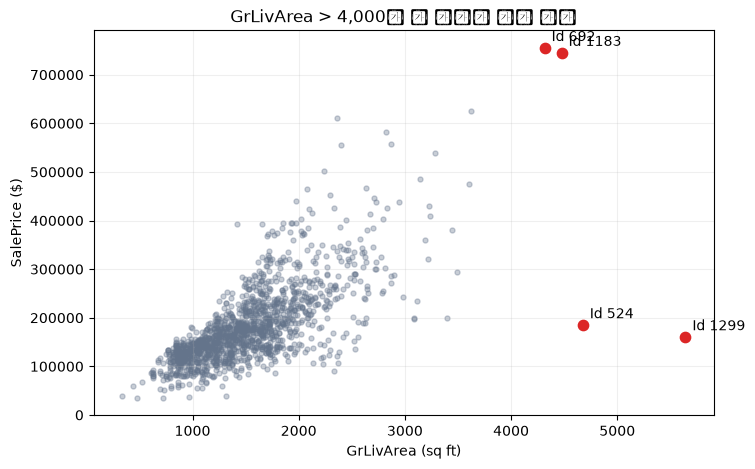

In [6]:
large_ids = [524, 692, 1183, 1299]
large_homes = (
    train[train["Id"].isin(large_ids)]
    .merge(
        oof_frames["Ridge all-features"][["Id", "log_residual", "predicted_saleprice"]],
        on="Id",
    )
    .merge(
        oof_frames["final MLP"][["Id", "log_residual", "predicted_saleprice"]],
        on="Id",
        suffixes=("_ridge", "_mlp"),
    )
)
large_homes["price_per_living_sf"] = large_homes["SalePrice"] / large_homes["GrLivArea"]
display(
    large_homes[
        [
            "Id", "GrLivArea", "SalePrice", "price_per_living_sf", "OverallQual",
            "Neighborhood", "SaleCondition", "YearBuilt", "YearRemodAdd", "YrSold",
            "predicted_saleprice_ridge", "log_residual_ridge",
            "predicted_saleprice_mlp", "log_residual_mlp",
        ]
    ].sort_values("Id")
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train["GrLivArea"], train["SalePrice"], s=13, alpha=0.35, color="#64748b")
selected = train[train["Id"].isin(large_ids)]
ax.scatter(selected["GrLivArea"], selected["SalePrice"], s=55, color="#dc2626")
for _, row in selected.iterrows():
    ax.annotate(f"Id {int(row['Id'])}", (row["GrLivArea"], row["SalePrice"]), xytext=(5, 5), textcoords="offset points")
ax.set(title="GrLivArea > 4,000인 네 주택의 가격 위치", xlabel="GrLivArea (sq ft)", ylabel="SalePrice ($)")
ax.grid(alpha=0.2)
plt.show()

### 5. 고정-fold 학습 제외 민감도

In [7]:
X = train.drop(columns=["SalePrice"])
y_log = np.log1p(pd.to_numeric(train["SalePrice"], errors="raise").to_numpy(float))
folds = make_folds(len(train), n_splits=5, seed=42)

def ridge_factory() -> Pipeline:
    return Pipeline(
        [
            ("preprocess", build_linear_preprocessor(FEATURE_GROUPS, 10, True)),
            ("model", Ridge(alpha=15.0, solver="lsqr")),
        ]
    )

sensitivity_variants = {
    "retain_all": [],
    "exclude_524": [524],
    "exclude_1299": [1299],
    "exclude_524_1299": [524, 1299],
    "exclude_692_1183": [692, 1183],
    "exclude_all_four": [524, 692, 1183, 1299],
}
sensitivity_results = {}
for name, excluded_ids in sensitivity_variants.items():
    result = evaluate_sklearn_cv(
        ridge_factory,
        X,
        y_log,
        folds,
        exclude_from_training=train["Id"].isin(excluded_ids).to_numpy(),
    )
    sensitivity_results[name] = result

reference = sensitivity_results["retain_all"]
sensitivity_rows = []
for name, excluded_ids in sensitivity_variants.items():
    result = sensitivity_results[name]
    paired_delta = np.asarray(result.fold_scores) - np.asarray(reference.fold_scores)
    sensitivity_rows.append(
        {
            "variant": name,
            "excluded_training_ids": excluded_ids,
            "cv_mean": result.cv_mean,
            "cv_std": result.cv_std,
            "oof_rmsle": result.oof_score,
            "delta_cv_mean": result.cv_mean - reference.cv_mean,
            "improved_folds": int((paired_delta < -1e-12).sum()),
            "unchanged_folds": int((np.abs(paired_delta) <= 1e-12).sum()),
            "fold_scores": result.fold_scores,
            "paired_fold_delta": paired_delta.tolist(),
        }
    )
sensitivity_summary = pd.DataFrame(sensitivity_rows)
display(sensitivity_summary)

,variant,excluded_training_ids,cv_mean,cv_std,oof_rmsle,delta_cv_mean,improved_folds,unchanged_folds,fold_scores,paired_fold_delta
0,retain_all,[],0.131910,0.029603,0.134541,0.000000,0,5,"[0.13078440035988154, 0.11668101992889157, 0.1...","[0.0, 0.0, 0.0, 0.0, 0.0]"
1,exclude_524,[524],0.131919,0.029598,0.134549,0.000009,2,1,"[0.1307823454333688, 0.11665806546929179, 0.18...","[-2.054926512728983e-06, -2.2954459599780486e-..."
2,exclude_1299,[1299],0.127303,0.032423,0.130565,-0.004607,4,1,"[0.12747630965404874, 0.10550448932774235, 0.1...","[-0.0033080907058327946, -0.011176530601149218..."
3,exclude_524_1299,"[524, 1299]",0.127306,0.032501,0.130583,-0.004604,4,1,"[0.12796239824932543, 0.10545043139071682, 0.1...","[-0.00282200211055611, -0.011230588538174754, ..."
4,exclude_692_1183,"[692, 1183]",0.136530,0.030048,0.139150,0.004620,1,0,"[0.13317449535367026, 0.11688145826005146, 0.1...","[0.0023900949937887273, 0.0002004383311598884,..."
5,exclude_all_four,"[524, 692, 1183, 1299]",0.128310,0.035183,0.132113,-0.003600,4,0,"[0.12794247754124569, 0.1054970326177327, 0.18...","[-0.0028419228186358503, -0.011183987311158869..."


이 민감도에서 Id 1299 제외가 방향을 주도한다. Id 1299가 validation에 들어간 fold 3은 학습 제외 여부와 무관해 점수가 동일하고, 나머지 4개 fold는 모두 개선됐다. Id 524 단독 제외는 평균 +0.000009로 사실상 중립이다. Id 692·1183 제외는 +0.004620 악화되어 두 고가 대면적 주택이 학습 분포를 지지함을 시사한다.

단, 이 결과는 **Ridge·seed 42·한 fold 설계**에 한정된다. 최종 PyTorch 모델과 다른 seed에서 Id 1299의 효과를 확인하기 전에는 확정 삭제가 아니라 유력 후보로만 둔다.

### 6. 테스트의 train 범위 밖 값

In [8]:
# Test predictor 범위·분포·개별 행은 분석하지 않는다.
extrapolation_summary = pd.DataFrame()

## Takeaways

1. **Id 1299 — High priority, confidence medium-high.** 5,642 sqft·품질 10인데 $160,000이며 두 모델 모두 크게 과대예측한다. Ridge에서 단독 제외가 영향을 받는 4개 fold 모두 개선됐다. 최종 MLP·추가 seed 민감도 전까지는 “제거 후보”로 둔다.
2. **Id 524 — Medium priority, confidence high for year error / low for row deletion.** 4,676 sqft·$184,750이며 `YearRemodAdd`가 판매연도보다 1년 늦다. 행 전체 삭제 효과는 거의 없으므로 미래연도 flag와 결측/보정 민감도가 우선이다.
3. **Id 692·1183 — Keep, confidence medium-high.** 극단적으로 크지만 고가 주택이며, 둘을 학습에서 제외하면 CV가 악화된다. Id 1183의 큰 과소예측은 `Abnorml` 판매 조건과 희소한 고가 영역의 모델 오차로 보고 보존한다.
4. **추가 잔차 후보 — Review, do not auto-delete.** Id 31, 411, 463, 496, 633, 813, 969, 1325 등은 두 모델 공통 큰 잔차다. 비정상 판매 조건이 많이 섞여 있어 타깃 오류보다 거래 맥락일 가능성이 있다.
5. **Test 사용 제한.** test predictor는 분석하지 않고 제출 형식 확인과 blind inference에만 사용한다.

현재 공유 수준은 **Share with caveats**다. 원자료·OOF 정렬·계산·고정-fold Ridge 재현은 검증됐지만, 최종 PyTorch에서의 Id 1299 제외 효과와 다중 seed 안정성은 아직 미검증이다.

In [9]:
metrics = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "share_with_caveats",
    "sources": records(source_summary),
    "grain": {"train_rows": len(train), "duplicate_train_ids": 0},
    "methods": {
        "univariate": "3*IQR outer fence on selected continuous variables",
        "domain_rules": "cross-field year, garage, basement, and living-area consistency",
        "conditional": "absolute OOF residual in log1p(SalePrice) from Ridge and final MLP",
        "sensitivity": "KFold(n_splits=5, shuffle=True, random_state=42); validation rows retained; exclusions only from fold training",
    },
    "iqr_summary": records(iqr_summary),
    "logic_summary": records(logic_summary),
    "logic_details": logic_details,
    "oof_summary": records(oof_summary),
    "oof_consensus_ids": consensus_ids,
    "oof_consensus_rows": records(consensus),
    "condition_profile": records(condition_profile),
    "large_home_rows": records(large_homes),
    "sensitivity": records(sensitivity_summary),
    "recommendation": {
        "primary_removal_candidate": [1299],
        "year_anomaly_keep_and_flag_train": [524],
        "keep_large_valid_train": [692, 1183],
        "review_not_auto_delete": [31, 411, 463, 496, 633, 813, 969, 1325],
        "unverified": ["final MLP exclusion sensitivity", "multi-seed stability"],
    },
}
METRICS_PATH.write_text(json.dumps(metrics, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

recomputed_ridge = float(np.sqrt(np.mean((ridge_oof["actual_log1p"] - ridge_oof["predicted_log1p"]) ** 2)))
recomputed_mlp = float(np.sqrt(np.mean((mlp_oof["actual_log1p"] - mlp_oof["predicted_log1p"]) ** 2)))
assert np.isclose(recomputed_ridge, 0.13454119569545403)
assert np.isclose(recomputed_mlp, 0.1343829550099314)
assert sensitivity_results["exclude_1299"].cv_mean < reference.cv_mean
assert sensitivity_results["exclude_692_1183"].cv_mean > reference.cv_mean
assert metrics["recommendation"]["primary_removal_candidate"] == [1299]
print(f"검증 완료: {METRICS_PATH.relative_to(ROOT)} 저장")

검증 완료: reports/outlier_metrics.json 저장
